In [ ]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import pairwise_distances

DATA_FILE = "pokopia_data.json"

In [ ]:
def generate_similarity_matrix():
    with open(DATA_FILE, 'r', encoding='utf-8') as f:
        pokemon_data = json.load(f)

    if not pokemon_data:
        print("The data file is empty.")
        return

    # Extract global list of unique features (Habitat + Favorites)
    feature_universe = set()
    pokemon_flat_features = {}

    for name, data in pokemon_data.items():
        combined = []
        if data["ideal_habitat"]:
            combined.append(data["ideal_habitat"])
        combined.extend(data["favorites"])

        pokemon_flat_features[name] = combined
        feature_universe.update(combined)

    sorted_features = sorted(list(feature_universe))

    # Construct binary vectors matrix (Rows = Pokemon, Columns = Features)
    binary_vectors = {}
    for name, features in pokemon_flat_features.items():
        binary_vectors[name] = [1 if feat in features else 0 for feat in sorted_features]

    df_vectors = pd.DataFrame.from_dict(binary_vectors, orient='index', columns=sorted_features)

    # Compute the pairwise matrix using Jaccard Similarity Metric
    boolean_matrix = df_vectors.astype(bool).values
    jaccard_distance_matrix = pairwise_distances(boolean_matrix, metric='jaccard')
    jaccard_similarity_matrix = 1 - jaccard_distance_matrix

    # Build clean output matrix DataFrame
    df_similarity = pd.DataFrame(
        jaccard_similarity_matrix,
        index=df_vectors.index,
        columns=df_vectors.index
    )

    df_similarity.to_csv("pokemon_home_similarity_matrix.csv")
    print("\n--- MATRIX GENERATION SUCCESSFUL ---")
    print(f"Matrix shape: {df_similarity.shape}")
    print("Saved matrix directly to 'pokemon_home_similarity_matrix.csv'")

    return df_similarity

In [ ]:
if not os.path.exists(DATA_FILE):
    print(f"{DATA_FILE} is required.")
else:
    print(f"Found cached '{DATA_FILE}'")

similarity_df = generate_similarity_matrix()

if similarity_df is not None:
    print("\nPreview of top 5x5 Matrix:")
    print(similarity_df.iloc[:5, :5])

Found cached 'pokopia_data.json'

--- MATRIX GENERATION SUCCESSFUL ---
Matrix shape: (308, 308)
Saved matrix directly to 'pokemon_home_similarity_matrix.csv'

Preview of top 5x5 Matrix:
            Bulbasaur   Ivysaur  Venusaur  Charmander  Charmeleon
Bulbasaur    1.000000  0.500000  0.500000    0.090909    0.000000
Ivysaur      0.500000  1.000000  0.714286    0.000000    0.000000
Venusaur     0.500000  0.714286  1.000000    0.000000    0.000000
Charmander   0.090909  0.000000  0.000000    1.000000    0.714286
Charmeleon   0.000000  0.000000  0.000000    0.714286    1.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def generate_similarity_heatmap(matrix_df, top_n=30):
    """
    Generates and saves a visual heatmap of the Pokémon similarity matrix.

    Parameters:
    matrix_df (DataFrame): The final Jaccard similarity DataFrame.
    top_n (int): Number of Pokémon to include in the visual plot
                 (300+ Pokémon is too dense for a single image, so we default to a sample).
    """
    print(f"\nGenerating heatmap for top {top_n} Pokémon...")

    # Slice the matrix to a readable size (e.g., first N Pokémon)
    sample_df = matrix_df.iloc[:top_n, :top_n]
    mapping = {
        1.0000: 6,
        0.7143: 5,
        0.5000: 4,
        0.3333: 3,
        0.2000: 2,
        0.0909: 1,
        0.0000: 0
    }

    df_counts = sample_df.round(4).map(lambda x: mapping.get(x, x))

    # Set up the matplotlib figure size
    plt.figure(figsize=(14, 12))

    # Create the heatmap using Seaborn
    # 'cmap' sets the color gradient (YlGnBu = Yellow-Green-Blue)
    # 'annot=True' displays the actual similarity score in the cell
    sns.heatmap(
        df_counts,
        cmap="YlGnBu",
        annot=True,
        fmt="g",
        linewidths=.5,
        cbar_kws={'label': 'Jaccard Similarity Score (0.0 - 1.0)'}
    )

    # Format labels and title
    plt.title(f"Pokémon Pokopia Home Similarity Heatmap (Top {top_n})", fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)

    # Adjust layout so labels don't get cut off
    plt.tight_layout()

    # Save the visual artifact
    output_image = "pokemon_home_heatmap.png"
    plt.savefig(output_image, dpi=300)
    plt.show()

    print(f"Heatmap successfully saved as '{output_image}'")

Found cached 'pokopia_data.json', skipping web scraper pipeline.

--- MATRIX GENERATION SUCCESSFUL ---
Matrix shape: (308, 308)
Saved matrix directly to 'pokemon_home_similarity_matrix.csv'

Generating heatmap for top 30 Pokémon...


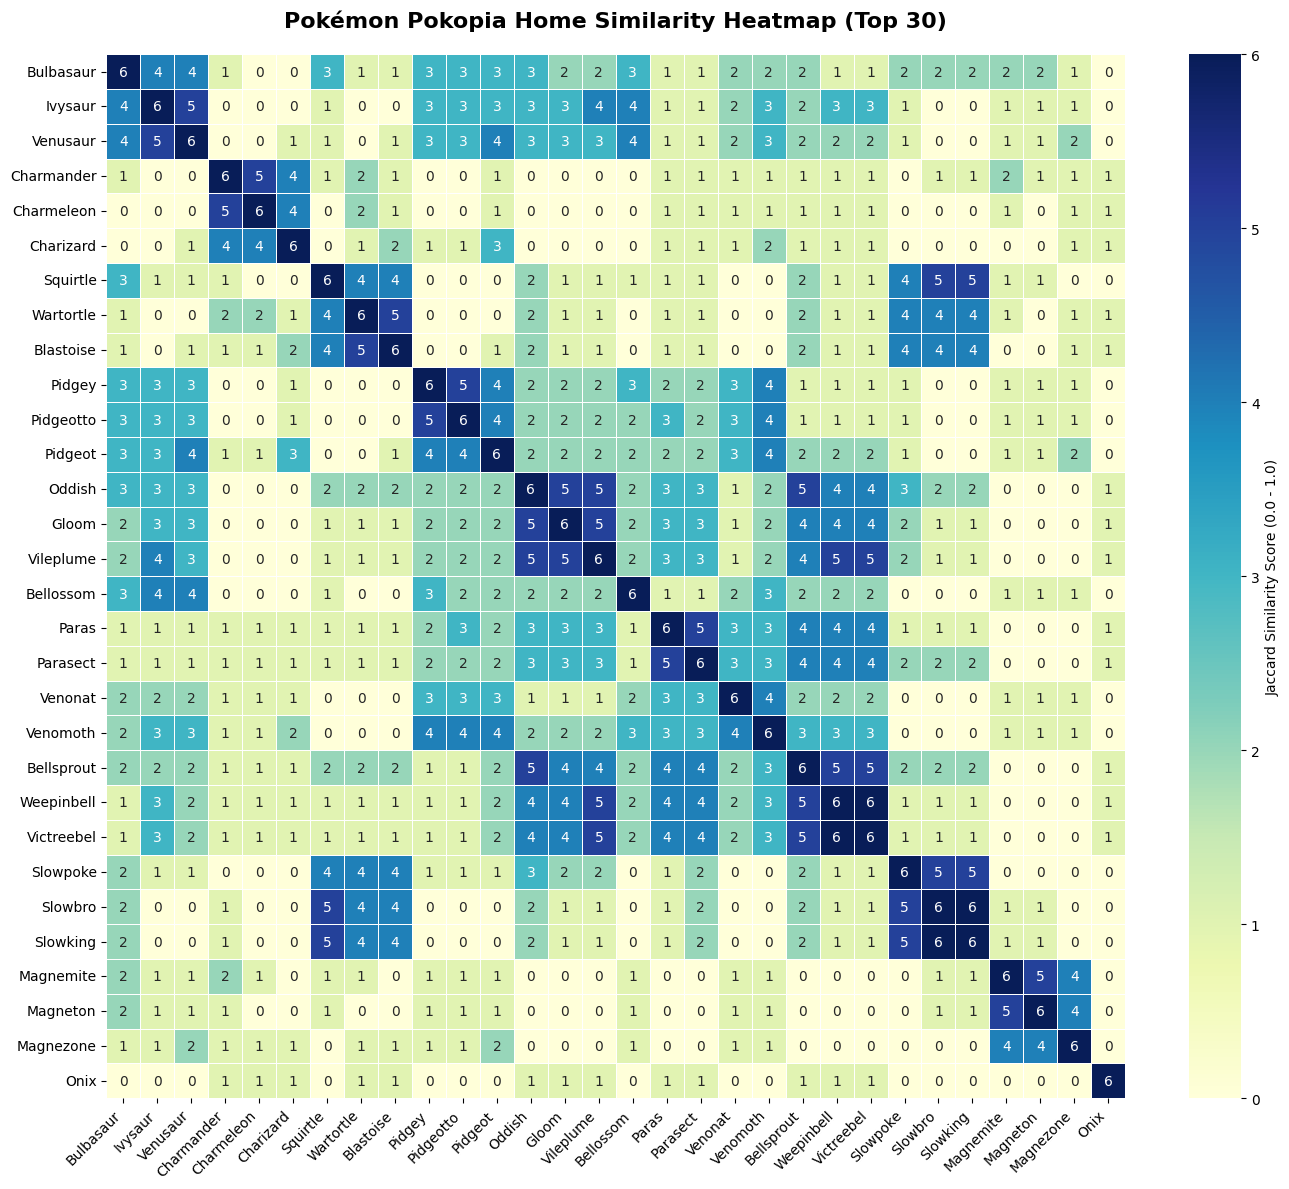

Heatmap successfully saved as 'pokemon_home_heatmap.png'


In [ ]:
similarity_df = generate_similarity_matrix()

if similarity_df is not None:
    generate_similarity_heatmap(similarity_df, top_n=30)

In [ ]:
import numpy as np
import pandas as pd
import random
import math
import matplotlib.pyplot as plt

# ==========================================
# 1. CORE DATA LOGIC & CONFIGURATION
# ==========================================
CSV_FILE = "pokemon_home_similarity_matrix.csv"

# Load data and ensure it pads to a multiple of 4
df_matrix = pd.read_csv(CSV_FILE, index_col=0)
pokemon_names = list(df_matrix.index)
while len(pokemon_names) % 4 != 0:
    pokemon_names.append("PADDING_DUMMY")

# Accelerate calculations via raw NumPy lookups
matrix = df_matrix.reindex(index=pokemon_names, columns=pokemon_names, fill_value=0.0).values
name_to_idx = {name: i for i, name in enumerate(pokemon_names)}

def calculate_house_score(poke_indices):
    """Calculates the sum of the 6 pairing scores inside a house of 4."""
    score = 0.0
    for i in range(4):
        for j in range(i + 1, 4):
            score += matrix[poke_indices[i], poke_indices[j]]
    return score

def evaluate_layout(layout_flat):
    """Calculates scores for all 77 houses simultaneously."""
    num_houses = len(layout_flat) // 4
    return np.array([calculate_house_score(layout_flat[h*4 : (h+1)*4]) for h in range(num_houses)])

# ==========================================
# 2. INTERCHANGEABLE FITNESS STRATEGIES
# ==========================================
import numpy as np
import random
import math
import pandas as pd

def fitness_strategy(scores, objective):
    """
    Calculates the fitness score based on the chosen societal philosophy.
    Since the SA engine maximizes fitness, minimization strategies are inverted.
    """
    objective = objective.lower()

    # 1. Utilitarian: Maximize the total happiness of the town
    if objective in ["max-sum", "max-average", "utilitarian"]:
        return np.sum(scores)

    # 2. Egalitarian: Maximize the comfort of the least happy home
    elif objective in ["max-min", "egalitarian"]:
        return np.min(scores)

    # 3. Harmony / Communism: Maximize average but heavily penalize variance (inequality)
    elif objective in ["min-variance", "harmony", "communism"]:
        # We subtract variance from the mean to balance quality and total equality
        return np.mean(scores) - np.var(scores)

    # 4. Elitist / Stratified: Maximize inequality/variance across the town
    elif objective in ["max-variance", "elitist"]:
        return np.var(scores)

    # 5. Chaos / Anti-Optimization: Minimize the sum of similarities
    elif objective in ["min-sum", "chaos"]:
        return -np.sum(scores)

    else:
        raise ValueError(f"Unknown optimization objective: {objective}")

# ==========================================
# 3. OPTIMIZATION ENGINE
# ==========================================
def optimize_layout(objective="max-min", steps=50000, initial_temp=1.0, cooling_rate=0.9995):
    """
    Simulated Annealing engine that tracks performance history over time.
    """
    # Standardize objective naming formatting
    objective = objective.lower()

    # Initialize a randomized deck of index tracking pointers
    current_layout = [name_to_idx[name] for name in pokemon_names]
    random.shuffle(current_layout)

    current_scores = evaluate_layout(current_layout)
    current_fitness = fitness_strategy(current_scores, objective)

    best_layout = list(current_layout)
    best_fitness = current_fitness
    best_scores = np.copy(current_scores)

    # History tracking arrays for graphing
    history = []

    T = initial_temp
    print(f"Running Optimization Strategy: [{objective.upper()}]")

    for step in range(steps):
        # Propose mutation: Swap two random items between houses
        idx1, idx2 = random.sample(range(len(current_layout)), 2)
        next_layout = list(current_layout)
        next_layout[idx1], next_layout[idx2] = next_layout[idx2], next_layout[idx1]

        # Evaluate performance
        next_scores = evaluate_layout(next_layout)
        next_fitness = fitness_strategy(next_scores, objective)

        # Metropolis Acceptance Criteria
        delta = next_fitness - current_fitness

        # If it's better, OR if it passes the thermal probability hurdle, accept it
        if delta > 0 or random.random() < math.exp(delta / T):
            current_layout = next_layout
            current_fitness = next_fitness
            current_scores = next_scores

            # Absolute best tracker update
            if next_fitness > best_fitness:
                best_layout = list(next_layout)
                best_fitness = next_fitness
                best_scores = np.copy(next_scores)

        # Append to performance tracking log
        history.append(current_fitness)

        # Cool system down gradually
        T *= cooling_rate

    # Standardize data framing out
    final_houses = []
    for h in range(len(best_layout) // 4):
        house_names = [pokemon_names[i] for i in best_layout[h*4 : (h+1)*4]]
        final_houses.append({
            "House_ID": h + 1,
            "Pokemon_1": house_names[0],
            "Pokemon_2": house_names[1],
            "Pokemon_3": house_names[2],
            "Pokemon_4": house_names[3],
            "Total_House_Score": best_scores[h]
        })

    return pd.DataFrame(final_houses), history

# ==========================================
# 4. GRAPH PLOTTING METHOD
# ==========================================
def plot_optimization_history(history, objective):
    """Renders the convergence and local minima escaping process."""
    plt.figure(figsize=(10, 5))
    plt.plot(history, color='#1f77b4', linewidth=1.5, label='Current Iteration Score')

    plt.title(f"Optimization Convergence History ({objective})", fontsize=12, fontweight='bold')
    plt.xlabel("Simulation Steps (Iterations)", fontsize=10)
    plt.ylabel("Evaluated Fitness Value", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Highlight the initial chaotic exploration vs settling phase
    plt.axvspan(0, len(history)//4, color='orange', alpha=0.1, label='Thermal Exploration Block')

    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"optimization_graph_{objective}.png", dpi=300)
    plt.show()

In [ ]:
# Define all 5 strategies to test
strategies = [
    "utilitarian",  # Max-Sum / Max-Average
    "egalitarian",  # Max-Min
    "harmony",      # Min-Variance / Communism
    "elitist",      # Max-Variance / Stratified
    "chaos"         # Min-Sum / Anti-Optimization
]

# Dictionary to hold dataframes and histories for all runs
results = {}

print("Starting Pokopia Societal Optimization Experiments...\n" + "="*50)

# 1. Run the optimization for each strategy
for strategy in strategies:
    # Run your updated optimize_layout function
    df_houses, history = optimize_layout(objective=strategy, steps=100000, cooling_rate=0.98)
    results[strategy] = df_houses

    # Save the results to a JSON file for each strategy
    output_filename = f"houses_{strategy}.json"
    df_houses.to_json(output_filename, orient="records", indent=4)
    print(f"  Saved houses for {strategy.upper()} to '{output_filename}'")

    print(f"✓ Completed strategy: {strategy.upper()}\n" + "-"*50)

print("\n" + "="*50 + "\nEXPERIMENT ANALYSIS AND METRICS\n" + "="*50)

# 2. Extract statistics, best layouts, and worst layouts for each approach
for strategy in strategies:
    df = results[strategy]

    print(f"\n[ APPROACH: {strategy.upper()} ]")
    print("-" * 40)

    # Calculate detailed distribution description (mean, std, min, max, percentiles)
    # Total_House_Score tracks individual house metrics across all 77 houses
    stats = df["Total_House_Score"].describe(percentiles=[0.25, 0.50, 0.75])

    print("📈 Distribution Metrics:")
    print(f"  Mean Score:   {stats['mean']:.4f}")
    print(f"  Std Dev:      {stats['std']:.4f}")
    print(f"  Minimum:      {stats['min']:.4f}")
    print(f"  25th Percent: {stats['25%']:.4f}")
    print(f"  50th (Median):{stats['50%']:.4f}")
    print(f"  75th Percent: {stats['75%']:.4f}")
    print(f"  Maximum:      {stats['max']:.4f}")
    print()

    # Identify the highest and lowest scoring house rows
    best_idx = df["Total_House_Score"].idxmax()
    worst_idx = df["Total_House_Score"].idxmin()

    best_house = df.loc[best_idx]
    worst_house = df.loc[worst_idx]

    # Print Best Layout configuration
    print(f"🏆 Absolute Best Layout (House ID: {best_house['House_ID']}, Score: {best_house['Total_House_Score']:.4f}):")
    print(f"  - {best_house['Pokemon_1']}")
    print(f"  - {best_house['Pokemon_2']}")
    print(f"  - {best_house['Pokemon_3']}")
    print(f"  - {best_house['Pokemon_4']}")
    print()

    # Print Worst Layout configuration
    print(f"❌ Absolute Worst Layout (House ID: {worst_house['House_ID']}, Score: {worst_house['Total_House_Score']:.4f}):")
    print(f"  - {worst_house['Pokemon_1']}")
    print(f"  - {worst_house['Pokemon_2']}")
    print(f"  - {worst_house['Pokemon_3']}")
    print(f"  - {worst_house['Pokemon_4']}")

    print("\n" + "="*50)

Starting Pokopia Societal Optimization Experiments...
Running Optimization Strategy: [UTILITARIAN]


/tmp/ipykernel_2505/1268006904.py:115: RuntimeWarning: overflow encountered in scalar divide
  if delta > 0 or random.random() < math.exp(delta / T):


  Saved houses for UTILITARIAN to 'houses_utilitarian.json'
✓ Completed strategy: UTILITARIAN
--------------------------------------------------
Running Optimization Strategy: [EGALITARIAN]
  Saved houses for EGALITARIAN to 'houses_egalitarian.json'
✓ Completed strategy: EGALITARIAN
--------------------------------------------------
Running Optimization Strategy: [HARMONY]
  Saved houses for HARMONY to 'houses_harmony.json'
✓ Completed strategy: HARMONY
--------------------------------------------------
Running Optimization Strategy: [ELITIST]
  Saved houses for ELITIST to 'houses_elitist.json'
✓ Completed strategy: ELITIST
--------------------------------------------------
Running Optimization Strategy: [CHAOS]
  Saved houses for CHAOS to 'houses_chaos.json'
✓ Completed strategy: CHAOS
--------------------------------------------------

EXPERIMENT ANALYSIS AND METRICS

[ APPROACH: UTILITARIAN ]
----------------------------------------
📈 Distribution Metrics:
  Mean Score:   3.0504
  S

In [ ]:
ditto_houses = best_df[best_df[['Pokemon_1', 'Pokemon_2', 'Pokemon_3', 'Pokemon_4']].isin(['Ditto']).any(axis=1)]
ditto_houses

,House_ID,Pokemon_1,Pokemon_2,Pokemon_3,Pokemon_4,Total_House_Score
19,20,Flaaffy,Ditto,Ampharos,Mareep,2.571429
